**DESION TREE**
1) entropy
2) information gain
3) gain index

**ENTROPY:** Entropy is a measure of randomness, disorder, or impurity in a dataset.
         In machine learning, it tells us how mixed or unpredictable the data points are at a specific node. range is 0 to 1

In [1]:
import pandas as pd

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

from sklearn import tree

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('Decision_Tree_Large_Practice_Dataset.xlsx')
print(df.head())

  Customer_ID    Age_Group Annual_Income Time_Spent_Mins Device_Used  \
0        C001       Senior        Medium            High      Tablet   
1        C002        Youth          High             Low      Mobile   
2        C003        Youth        Medium            High      Tablet   
3        C004       Senior           Low             Low      Tablet   
4        C005  Middle-Aged        Medium             Low      Mobile   

  Items_in_Cart Discount_Available Made_Purchase  
0          Many                 No            No  
1           Few                 No            No  
2           Few                Yes           Yes  
3           Few                 No            No  
4           Few                 No            No  


In [3]:
df.isnull().sum()

Customer_ID           0
Age_Group             0
Annual_Income         0
Time_Spent_Mins       0
Device_Used           0
Items_in_Cart         0
Discount_Available    0
Made_Purchase         0
dtype: int64

In [4]:
df.duplicated().sum()

0

In [5]:
X = df.drop(columns=['Customer_ID', 'Made_Purchase'])
y = df['Made_Purchase'].map({'Yes': 1, 'No': 0})

In [6]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [8]:
X

,Age_Group,Annual_Income,Time_Spent_Mins,Device_Used,Items_in_Cart,Discount_Available
0,Senior,Medium,High,Tablet,Many,No
1,Youth,High,Low,Mobile,Few,No
2,Youth,Medium,High,Tablet,Few,Yes
3,Senior,Low,Low,Tablet,Few,No
4,Middle-Aged,Medium,Low,Mobile,Few,No
...,...,...,...,...,...,...
115,Senior,Low,Low,Tablet,Many,No
116,Middle-Aged,Low,High,Mobile,Few,Yes
117,Youth,Medium,Low,Tablet,Many,No
118,Senior,Low,Medium,Mobile,Many,Yes



--- Model Evaluation ---
Accuracy Score: 70.83%

Classification Report:
              precision    recall  f1-score   support

          No       0.81      0.76      0.79        17
         Yes       0.50      0.57      0.53         7

    accuracy                           0.71        24
   macro avg       0.66      0.67      0.66        24
weighted avg       0.72      0.71      0.71        24



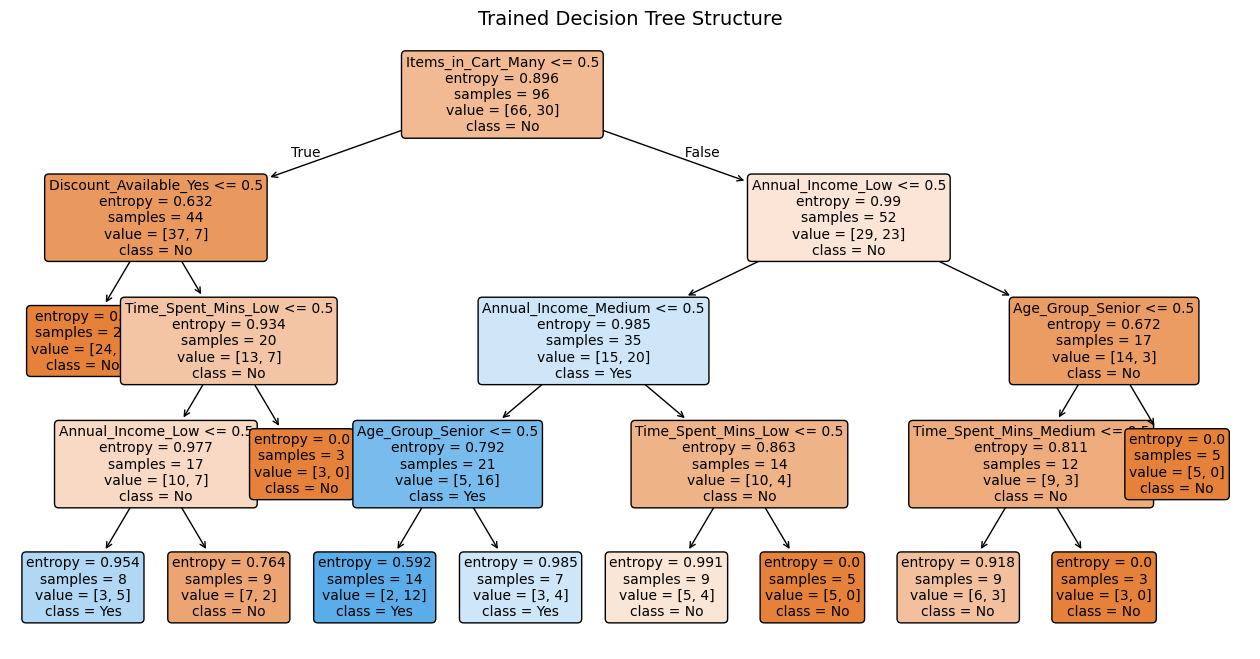

In [9]:
model = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("\n--- Model Evaluation ---")
print(f"Accuracy Score: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

plt.figure(figsize=(16, 8))
plot_tree(
    model, 
    feature_names=X_encoded.columns, 
    class_names=['No', 'Yes'], 
    filled=True, 
    rounded=True, 
    fontsize=10
)
plt.title("Trained Decision Tree Structure", fontsize=14)
plt.show()

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import r2_score, accuracy_score

In [12]:
file_path = "Decision_Tree_Large_Practice_Dataset.xlsx"
df = pd.read_excel(file_path)

In [13]:
X = df.drop(columns=['Customer_ID', 'Made_Purchase'])
y = df['Made_Purchase'].map({'Yes': 1, 'No': 0})

In [14]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [16]:
param = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [2, 3, 4, 5, 6, 7, 8, 10, None],
    'min_samples_split': [2, 3, 5, 10],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': [None, 'sqrt', 'log2']
}

In [17]:
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param,
    cv=5,
    scoring='accuracy', 
    n_jobs=-1
)

In [18]:
grid_search.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [2, 3, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [19]:
print("Best Parameters Found By GridSearch:")
print(grid_search.best_params_)

Best Parameters Found By GridSearch:
{'criterion': 'gini', 'max_depth': 7, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 3}


In [20]:
best_model = grid_search.best_estimator_

In [21]:
y_pred = best_model.predict(X_test)

In [22]:
accuracy = accuracy_score(y_test, y_pred)
print(f"\nTuned Model Test Accuracy: {accuracy * 100:.2f}%")


Tuned Model Test Accuracy: 75.00%


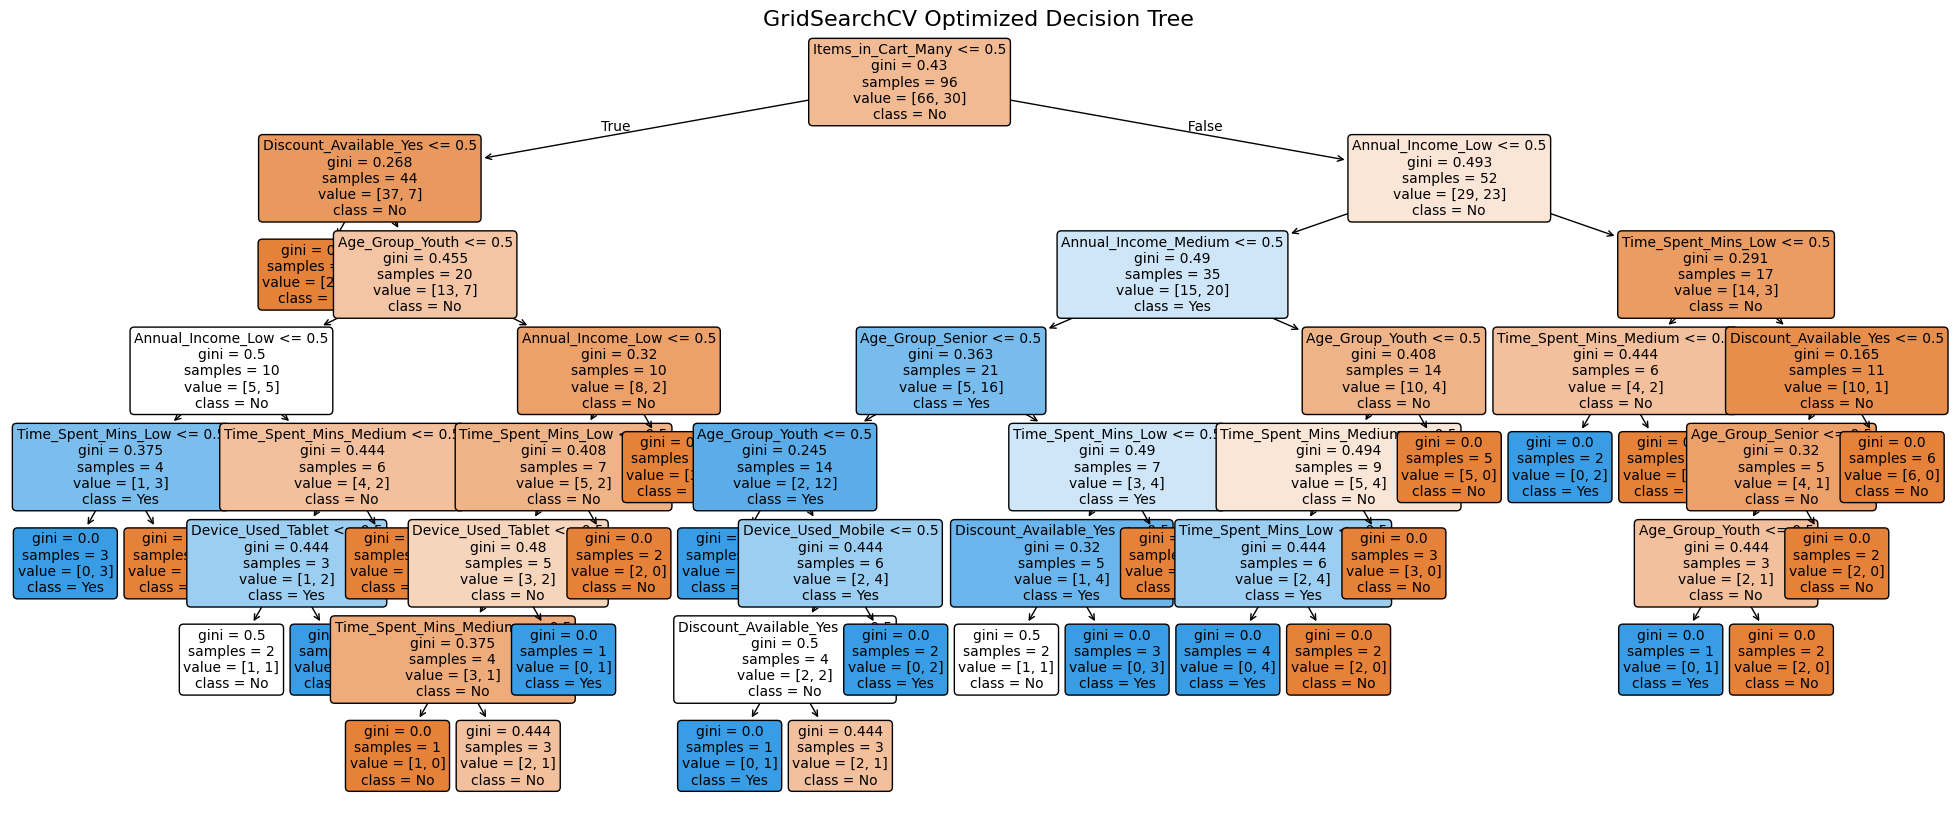

In [23]:
plt.figure(figsize=(25, 10))

tree.plot_tree(
    best_model,
    filled=True,
    feature_names=X_train.columns,
    class_names=['No', 'Yes'],
    rounded=True,
    fontsize=10
)

plt.title("GridSearchCV Optimized Decision Tree", fontsize=16)
plt.show()